In [1]:
import torch
import numpy as np 
import os 
import sys
from pathlib import Path
ls = os.path.abspath('../')
sys.path.append(ls)

In [2]:
from model.camera.dataset_loader import DatasetLoader

In [3]:
json_path = '../nerfdataset/lot1/transforms.json'
dataset = DatasetLoader(json_path)
print(f"Number of images in the dataset: {len(dataset.frames)}")

Number of images in the dataset: 79


In [5]:
first_cam = dataset.frames[0]
print(f"Image path: {first_cam.image_path}")
print(f"Rotation matrix R:\n{first_cam.R}")
print(f"Translation t:\n{first_cam.t}")
print(f"Projection matrix P:\n{first_cam.P}")

Image path: ./nerfdataset/lot1/images/IMG_0365.png
Rotation matrix R:
[[ 0.9700984   0.12537129 -0.20782495]
 [-0.22114043  0.10366526 -0.96971667]
 [-0.10003041  0.9866791   0.12829016]]
Translation t:
[[-0.92515504]
 [-4.6276317 ]
 [ 0.3826367 ]]
Projection matrix P:
tensor([[ 9.6443e+02,  6.3594e+02, -1.5195e+02, -7.7283e+02],
        [-2.9978e+02,  7.8194e+02, -9.2764e+02, -4.5835e+03],
        [-1.0003e-01,  9.8668e-01,  1.2829e-01,  3.8264e-01]])


In [5]:
import numpy as np
point3d = np.array([[0.0, 0.0, 0.0]])  # origine
pixel = first_cam.project(point3d)
print(f"Projection du point {point3d} -> pixel: {pixel}")

Projection du point [[0. 0. 0.]] -> pixel: tensor([[ -2019.7426, -11978.7920]], dtype=torch.float64)


In [6]:
# exemple pixel -> direction rayon
pixels = np.array([[first_cam.intrinsics.cx, first_cam.intrinsics.cy]])
ray_dir = first_cam.unproject(pixels)
print(f"Direction du rayon pour le pixel {pixels}: {ray_dir}")

Direction du rayon pour le pixel [[511.5 682.5]]: [[0. 0. 1.]]


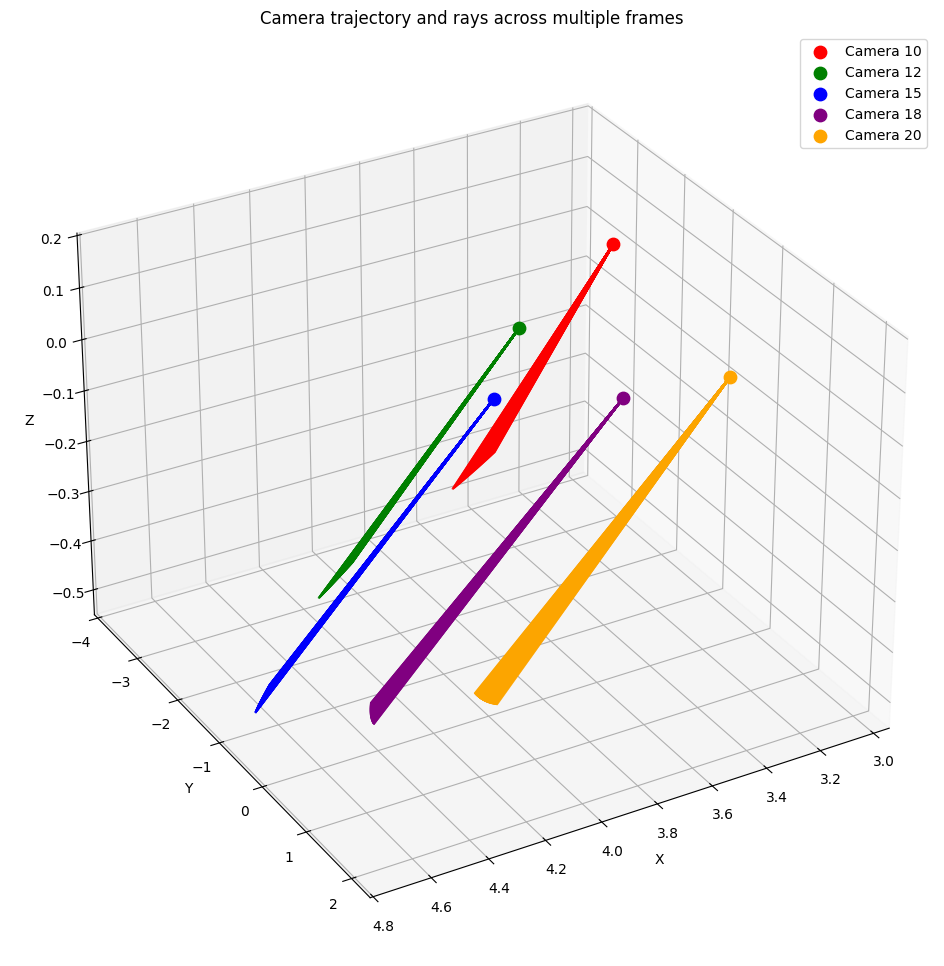

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

frames_indices = [10, 12, 15, 18, 20]  
n_rays = 300  

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'green', 'blue', 'purple', 'orange']

for idx, color in zip(frames_indices, colors):
    frame = dataset.frames[idx]
    H, W = int(frame.intrinsics.h), int(frame.intrinsics.w)
    rays_origin, rays_direction = frame.rays(H, W)
    
    rays_origin_np = rays_origin[:n_rays].cpu().numpy()
    rays_direction_np = rays_direction[:n_rays].cpu().numpy()
    
    for origin, direction in zip(rays_origin_np, rays_direction_np):
        ax.plot(
            [origin[0], origin[0] + direction[0]],
            [origin[1], origin[1] + direction[1]],
            [origin[2], origin[2] + direction[2]],
            color=color,
            alpha=0.3
        )
    
    ax.scatter(rays_origin_np[0,0], rays_origin_np[0,1], rays_origin_np[0,2],
               color=color, s=80, label=f'Camera {idx}')

# Paramètres du plot
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Camera trajectory and rays across multiple frames")
ax.legend()
ax.view_init(elev=30, azim=60)
plt.show()


In [8]:
from model.dataset import BaseNeRFDataset, RayNeRFDataset

In [9]:
json_path = "../nerfdataset/lot1/transforms.json"
dataset = RayNeRFDataset(
    json_path=json_path,
    data_root="../nerfdataset/lot1/images",
    cam_id=True,
    device="cpu"
)
print(f"Number of cameras: {dataset.num_images()}")
print(f"Image size: {dataset.height_width()}")
print(f"Total rays: {len(dataset)}")


Number of cameras: 79
Image size: (1365, 1023)
Total rays: 110315205


In [10]:
sample = dataset[0]
print(f"Sample keys: {sample.keys()}")
if 'target_s' in sample and sample['target_s'] is not None:
    print(f"Target shape: {sample['target_s'].shape}")
    print(f"Target range: [{sample['target_s'].min():.3f}, {sample['target_s'].max():.3f}]")


Sample keys: dict_keys(['rays', 'target_s', 'cam_id'])
Target shape: torch.Size([3])
Target range: [0.000, 0.000]


In [11]:
batch = dataset.get_full_batch(4)
print(f"\nBatch rays shape: {batch['rays'].shape}")
print(f"Batch cam_ids: {batch['cam_id']}")


Batch rays shape: torch.Size([4, 2, 3])
Batch cam_ids: tensor([16, 40, 70, 77])


In [12]:
import torch
import matplotlib.pyplot as plt

json_path = "../nerfdataset/lot1/transforms.json"

dataset = RayNeRFDataset(
    json_path=json_path,
    data_root="../nerfdataset/lot1/images",

    cam_id=True,
    device="cpu"
)

print("Checking image statistics...")

for i in range(3):  # Check first 3 images
    img = dataset.rgbs[i]
    print(f"\nImage {i}:")
    print(f"  Min: {img.min():.3f}")
    print(f"  Max: {img.max():.3f}")
    print(f"  Mean: {img.mean():.3f}")
    print(f"  Non-zero pixels: {(img.sum(dim=-1) > 0.01).sum()} / {dataset.H * dataset.W}")
    
    # Check center pixel
    center_y, center_x = dataset.H // 2, dataset.W // 2
    print(f"  Center pixel ({center_y},{center_x}): {img[center_y, center_x].tolist()}")

# Visualize a small patch
print("\nChecking a 10x10 patch from center of first image:")
center_y, center_x = dataset.H // 2, dataset.W // 2
patch = dataset.rgbs[0, center_y-5:center_y+5, center_x-5:center_x+5]
print(f"Patch shape: {patch.shape}")
print(f"Patch mean: {patch.mean():.3f}")
print(f"Patch non-zero: {(patch.sum(dim=-1) > 0.01).sum()} / 100")

# Check random pixels
print("\nChecking 10 random pixels from first image:")
import random
for _ in range(10):
    y = random.randint(0, dataset.H-1)
    x = random.randint(0, dataset.W-1)
    pixel = dataset.rgbs[0, y, x]
    print(f"  Pixel ({y},{x}): {pixel.tolist()}")

# Test that __getitem__ works for non-zero pixels
print("\nFinding first non-zero pixel...")
found = False
for y in range(dataset.H):
    for x in range(dataset.W):
        if dataset.rgbs[0, y, x].sum() > 0.01:
            pixel_idx = y * dataset.W + x
            sample_idx = 0 * (dataset.H * dataset.W) + pixel_idx
            sample = dataset[sample_idx]
            print(f"First non-zero pixel at ({y},{x})")
            print(f"  Direct access: {dataset.rgbs[0, y, x].tolist()}")
            print(f"  Sample target: {sample['target_s'].tolist()}")
            found = True
            break
    if found:
        break

if not found:
    print("All pixels in first image are black!")

Checking image statistics...

Image 0:
  Min: 0.000
  Max: 1.000
  Mean: 0.105
  Non-zero pixels: 507476 / 1396395
  Center pixel (682,511): [0.10196078568696976, 0.10196078568696976, 0.10196078568696976]

Image 1:
  Min: 0.000
  Max: 1.000
  Mean: 0.110
  Non-zero pixels: 490011 / 1396395
  Center pixel (682,511): [0.14509804546833038, 0.10196078568696976, 0.08627451211214066]

Image 2:
  Min: 0.000
  Max: 1.000
  Mean: 0.116
  Non-zero pixels: 519093 / 1396395
  Center pixel (682,511): [0.26274511218070984, 0.1921568661928177, 0.1764705926179886]

Checking a 10x10 patch from center of first image:
Patch shape: torch.Size([10, 10, 3])
Patch mean: 0.125
Patch non-zero: 100 / 100

Checking 10 random pixels from first image:
  Pixel (734,848): [0.2705882489681244, 0.29411765933036804, 0.2980392277240753]
  Pixel (384,362): [0.5137255191802979, 0.45098039507865906, 0.41960784792900085]
  Pixel (661,63): [0.0, 0.0, 0.0]
  Pixel (1074,314): [0.0, 0.0, 0.0]
  Pixel (643,292): [0.196078434586

In [4]:
from model.encoding import PositionalEncoding, IntegratedPositionalEncoding
pe = PositionalEncoding(L=10, include_input=True, trainable=False, periodic_fn=[torch.sin, torch.cos])
position = torch.tensor([[1.0, 2.0, 3.0]])
encoded = pe(position)
encoded.shape

torch.Size([1, 63])

In [5]:
ipe = IntegratedPositionalEncoding(
    L=10,          # juste pour garder ton paramètre L
    num_freqs=10,  # nombre de fréquences
    include_input=True,
    log_sampling=True,
    trainable=False
)

In [6]:
mu = torch.tensor([[1.0, 2.0, 3.0]])
cov = torch.tensor([[0.01, 0.02, 0.03]])
encoded = ipe(mu, cov)
encoded.shape

torch.Size([1, 63])

In [8]:
encoded

tensor([[[ 0.0279,  0.7950, -1.2120,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.1721,  1.6698,  0.4686,  ..., -0.0000, -0.0000, -0.0000],
         [-0.4942,  0.9055, -0.0619,  ..., -0.0000, -0.0000, -0.0000],
         [-0.6301,  1.1618,  1.6137,  ..., -0.0000,  0.0000,  0.0000],
         [ 0.9010,  0.4613, -0.1062,  ...,  0.0000, -0.0000,  0.0000]],

        [[-0.2869,  0.2248, -0.9142,  ..., -0.0000, -0.0000,  0.0000],
         [-0.9283, -0.0594, -0.2343,  ..., -0.0000,  0.0000,  0.0000],
         [ 1.1800, -0.5151,  0.3874,  ...,  0.0000,  0.0000, -0.0000],
         [ 0.3984,  0.1953, -0.6375,  ...,  0.0000, -0.0000, -0.0000],
         [ 0.1776, -1.0378, -0.7649,  ...,  0.0000, -0.0000,  0.0000]],

        [[-0.1642, -0.8573, -0.7185,  ..., -0.0000, -0.0000, -0.0000],
         [-0.7378,  1.6031, -1.6519,  ..., -0.0000,  0.0000, -0.0000],
         [ 0.1600,  1.0247, -1.2191,  ..., -0.0000,  0.0000,  0.0000],
         [-0.0196,  1.8497, -0.0109,  ..., -0.0000,  0.0000, -0.0000],
  

In [ ]:
B, N = 4, 5
mu = torch.randn(B, N, 3)
cov = torch.abs(torch.randn(B, N, 3)) * 0.1

encoded = ipe(mu, cov)
print("Batch test encoded shape:", encoded.shape)
# Expected: [B, N, 63]


Batch test encoded shape: torch.Size([4, 5, 63])


In [9]:
B, N = 4, 5
position = torch.randn(B, N, 3)
encoded = pe(position)

In [10]:
position.shape, encoded.shape

(torch.Size([4, 5, 3]), torch.Size([4, 5, 63]))

In [10]:
from model.encoding import HashEncoding
encoder = HashEncoding(
    L=4,           
    F=2,            
    input_dim=3, 
    include_input=True,
    trainable=True
)
x = torch.randn(1, 10, 3)
encoded = encoder(x)
encoded.shape

torch.Size([1, 10, 11])

In [11]:
print(f"  Min:  {encoded.min():.4f}")
print(f"  Max:  {encoded.max():.4f}")
print(f"  Mean: {encoded.mean():.4f}")
print(f"  Std:  {encoded.std():.4f}")

  Min:  -3.2646
  Max:  1.7781
  Mean: -0.0208
  Std:  0.5231


In [12]:
encoded.sum().backward()
print(f"\n✓ Gradient OK!")


✓ Gradient OK!
